<a href="https://colab.research.google.com/github/mannan234-cmd/InternCircle-Data-Science-AI/blob/main/InternCircle_Task_02_Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# InternCircle – Data Science & AI Internship

## Task 02: Exploratory Data Analysis (EDA) on Titanic Dataset

**Intern:** Muhammad Mannan Masud  
**Track:** Data Science & AI    
**Task:** Exploratory Data Analysis (EDA) on Titanic

### Objective
Load and analyze the Titanic dataset using Pandas to discover
statistical insights, understand the structure of the data,
handle missing values and duplicates, and perform grouping
and aggregation analysis.

In [1]:
import pandas as pd
import numpy as np

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.shape

(891, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


In [10]:
df[["Age", "Cabin", "Embarked"]].isnull().sum()

,0
Age,177
Cabin,687
Embarked,2


In [13]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [14]:
# Handle missing Age values using the median

df["Age"] = df["Age"].fillna(df["Age"].median())

# Handle missing Embarked values using the mode

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [15]:
# Check missing values after handling

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [16]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
# Check dataset after cleaning

print("Dataset shape after cleaning:", df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum())

Dataset shape after cleaning: (891, 11)

Remaining missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [18]:
# Count passengers by survival status

survival_counts = df["Survived"].value_counts()

print("Survival counts:")
print(survival_counts)

Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64


In [19]:
# Calculate overall survival rate

survival_rate = df["Survived"].mean() * 100

print(f"Overall survival rate: {survival_rate:.2f}%")

Overall survival rate: 38.38%


In [20]:
# Count passengers by gender

gender_counts = df["Sex"].value_counts()

print("Passengers by gender:")
print(gender_counts)

Passengers by gender:
Sex
male      577
female    314
Name: count, dtype: int64


In [21]:
# Calculate survival rate by gender

gender_survival = (
    df.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival rate by gender:")
print(gender_survival)

Survival rate by gender:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


In [22]:
# Grouping and aggregation by gender

gender_analysis = df.groupby("Sex")["Survived"].agg(
    ["count", "sum", "mean"]
)

gender_analysis["mean"] = gender_analysis["mean"] * 100

gender_analysis = gender_analysis.rename(
    columns={
        "count": "Passengers",
        "sum": "Survivors",
        "mean": "Survival_Rate_Percent"
    }
)

gender_analysis

,Passengers,Survivors,Survival_Rate_Percent
Sex,,,
female,314,233,74.203822
male,577,109,18.890815


In [23]:
# Number of passengers in each class

class_counts = df["Pclass"].value_counts().sort_index()

print("Passengers in each class:")
print(class_counts)

Passengers in each class:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [24]:
# Survival rate by passenger class

class_survival = (
    df.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival rate by passenger class:")
print(class_survival)

Survival rate by passenger class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


In [25]:
# Grouping and aggregation by passenger class

class_analysis = df.groupby("Pclass")["Survived"].agg(
    ["count", "sum", "mean"]
)

class_analysis["mean"] = class_analysis["mean"] * 100

class_analysis = class_analysis.rename(
    columns={
        "count": "Passengers",
        "sum": "Survivors",
        "mean": "Survival_Rate_Percent"
    }
)

class_analysis

,Passengers,Survivors,Survival_Rate_Percent
Pclass,,,
1,216,136,62.962963
2,184,87,47.282609
3,491,119,24.236253


In [26]:
# Average age by passenger class

average_age_by_class = (
    df.groupby("Pclass")["Age"]
    .mean()
    .round(2)
)

print("Average age by passenger class:")
print(average_age_by_class)

Average age by passenger class:
Pclass
1    36.81
2    29.77
3    25.93
Name: Age, dtype: float64


In [27]:
# Survival rate by gender and passenger class

gender_class_survival = (
    df.groupby(["Sex", "Pclass"])["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival rate by gender and passenger class:")
print(gender_class_survival)

Survival rate by gender and passenger class:
Sex     Pclass
female  1         96.81
        2         92.11
        3         50.00
male    1         36.89
        2         15.74
        3         13.54
Name: Survived, dtype: float64


In [28]:
# Average passenger age

average_age = df["Age"].mean()

print(f"Average passenger age: {average_age:.2f} years")

Average passenger age: 29.36 years


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


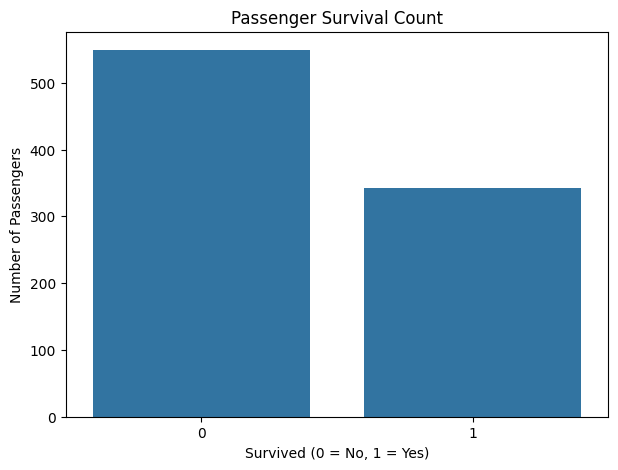

In [30]:
# Survival count visualization

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Survived")

plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

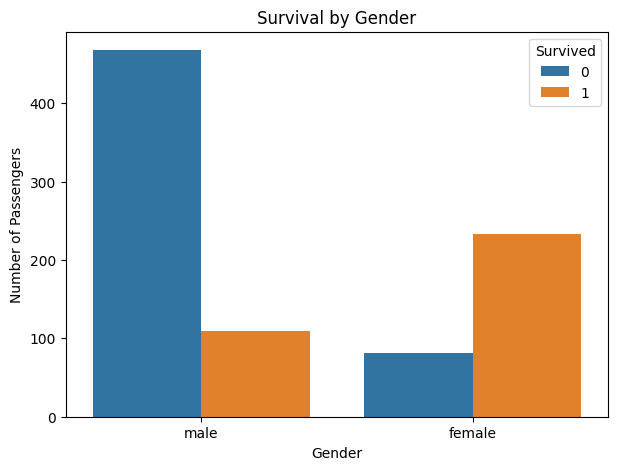

In [31]:
# Survival by gender

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

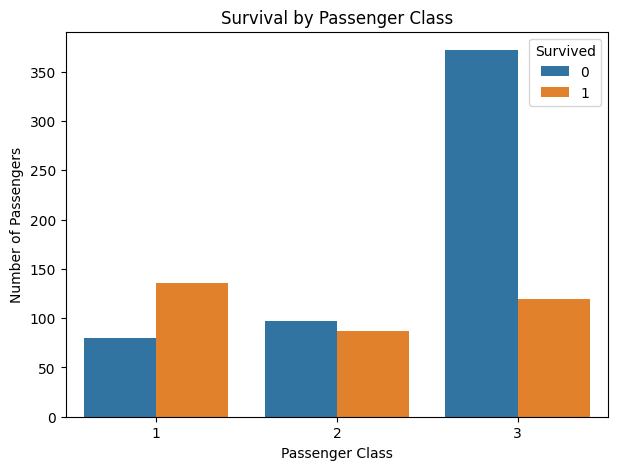

In [32]:
# Survival by passenger class

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

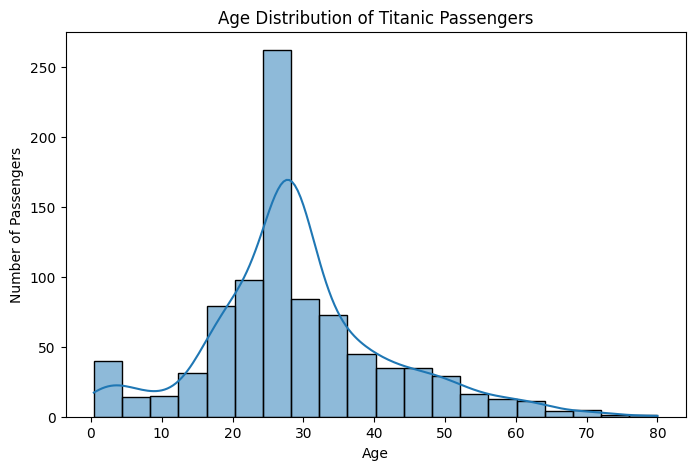

In [33]:
# Age distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

# Key Insights

## Dataset

- The Titanic dataset contains passenger information including
  survival status, passenger class, name, gender, age, ticket,
  fare, and embarkation port.

## Data Cleaning

- Missing values were identified using `isnull().sum()`.
- Missing `Age` values were handled using the median.
- Missing `Embarked` values were handled using the mode.
- Duplicate records were checked and removed where necessary.
- The dataset used in this analysis does not contain a `Cabin` column.

## Statistical Analysis

- The overall survival rate was calculated.
- Passenger survival was analyzed by gender.
- Passenger survival was analyzed by passenger class.
- Average age and fare were calculated for different passenger classes.
- Grouping and aggregation were performed using Pandas.

## EDA Findings

- Survival outcomes differed between male and female passengers.
- Survival outcomes also differed across passenger classes.
- Passenger age and fare varied across different passenger classes.
- Grouping passenger data by gender and class provided additional
  insights into survival patterns.

## Conclusion

The Titanic dataset was successfully explored using Pandas.
The analysis demonstrated DataFrame operations, statistical
summaries, missing-value handling, duplicate handling, grouping,
aggregation, and basic visualization.